# Notebook 04 — Statistical Analysis
**Project:** Credit Risk & Loan Default Analysis  
**Objective:** Apply statistical methods to validate findings from EDA and quantify risk factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/loans_cleaned.csv', low_memory=False)
print(f'Loaded: {df.shape}')

Loaded: (1348099, 32)


## 1. Hypothesis Testing — Does interest rate differ between defaulted and non-defaulted loans?

In [2]:
defaulted = df[df['default_flag'] == 1]['int_rate'].dropna()
non_defaulted = df[df['default_flag'] == 0]['int_rate'].dropna()

t_stat, p_value = stats.ttest_ind(defaulted, non_defaulted)

print('H0: Mean interest rate is the same for defaulted and non-defaulted loans')
print(f'Mean int_rate (Defaulted):     {defaulted.mean():.2f}%')
print(f'Mean int_rate (Non-defaulted): {non_defaulted.mean():.2f}%')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.4e}')
print()
if p_value < 0.05:
    print('Result: REJECT H0 — statistically significant difference in interest rates.')
else:
    print('Result: FAIL TO REJECT H0 — no significant difference.')
print('Business Insight: [Write what this means for the lender]')

H0: Mean interest rate is the same for defaulted and non-defaulted loans
Mean int_rate (Defaulted):     15.71%
Mean int_rate (Non-defaulted): 12.63%
T-statistic: 310.7972
P-value:     0.0000e+00

Result: REJECT H0 — statistically significant difference in interest rates.
Business Insight: [Write what this means for the lender]


## 2. Hypothesis Testing — Does DTI differ significantly between defaulted vs non-defaulted?

In [3]:
defaulted_dti = df[df['default_flag'] == 1]['dti'].dropna()
non_defaulted_dti = df[df['default_flag'] == 0]['dti'].dropna()

t_stat_dti, p_value_dti = stats.ttest_ind(defaulted_dti, non_defaulted_dti)

print('H0: Mean DTI is the same for defaulted and non-defaulted loans')
print(f'Mean DTI (Defaulted):     {defaulted_dti.mean():.2f}')
print(f'Mean DTI (Non-defaulted): {non_defaulted_dti.mean():.2f}')
print(f'P-value: {p_value_dti:.4e}')
if p_value_dti < 0.05:
    print('Result: REJECT H0 — DTI is significantly higher for defaulted loans.')
print('Business Insight: [Write what this means for underwriting policy]')

H0: Mean DTI is the same for defaulted and non-defaulted loans
Mean DTI (Defaulted):     19.94
Mean DTI (Non-defaulted): 17.66
P-value: 0.0000e+00
Result: REJECT H0 — DTI is significantly higher for defaulted loans.
Business Insight: [Write what this means for underwriting policy]


## 3. Chi-Square Test — Is loan grade associated with default?

In [4]:
contingency = pd.crosstab(df['grade'], df['default_flag'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print('Chi-Square Test: Grade vs Default')
print(f'Chi2 statistic: {chi2:.2f}')
print(f'P-value: {p:.4e}')
print(f'Degrees of freedom: {dof}')
if p < 0.05:
    print('Result: Loan grade is significantly associated with default.')
print('Business Insight: [Write what this means]')

Chi-Square Test: Grade vs Default
Chi2 statistic: 92315.99
P-value: 0.0000e+00
Degrees of freedom: 6
Result: Loan grade is significantly associated with default.
Business Insight: [Write what this means]


## 4. Logistic Regression — Risk Factor Quantification

In [5]:
features = ['int_rate', 'annual_inc', 'dti', 'fico_avg', 'delinq_2yrs',
            'revol_util', 'open_acc', 'credit_age_years', 'loan_amnt']
features = [f for f in features if f in df.columns]

model_df = df[features + ['default_flag']].dropna()
X = model_df[features]
y = model_df['default_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression Results ===')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215743
           1       0.51      0.06      0.10     53871

    accuracy                           0.80    269614
   macro avg       0.66      0.52      0.50    269614
weighted avg       0.75      0.80      0.73    269614

ROC-AUC Score: 0.6935


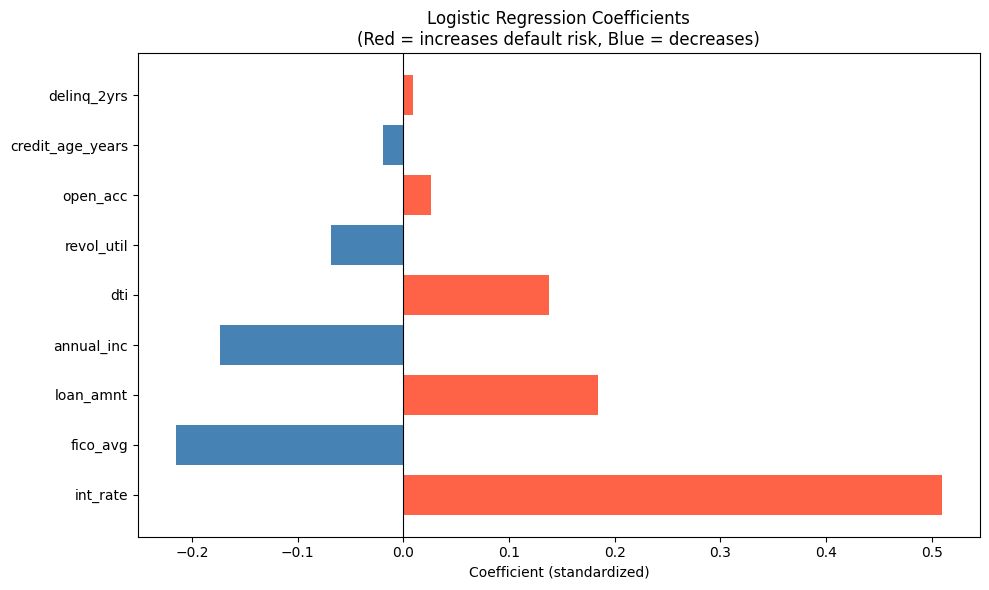

Business Insight: [Write top 3 risk factors and what a credit officer should do with this]


In [6]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({'feature': features, 'coefficient': model.coef_[0]})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Red = increases default risk, Blue = decreases)')
plt.xlabel('Coefficient (standardized)')
plt.tight_layout()
plt.savefig('../tableau/screenshots/logistic_regression_coefficients.png', dpi=150)
plt.show()
print('Business Insight: [Write top 3 risk factors and what a credit officer should do with this]')

## 5. ROC Curve

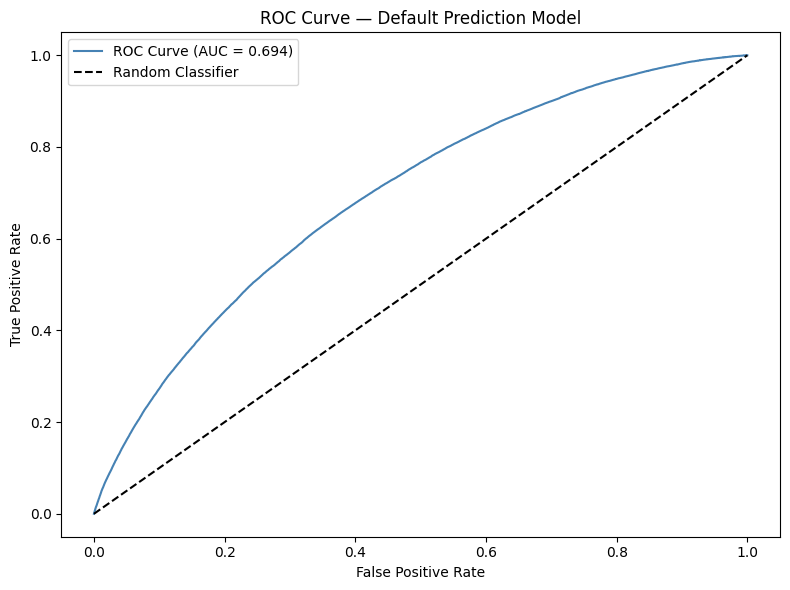

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Default Prediction Model')
plt.legend()
plt.tight_layout()
plt.savefig('../tableau/screenshots/roc_curve.png', dpi=150)
plt.show()

## 6. Risk Segmentation — Default Rate by FICO Band

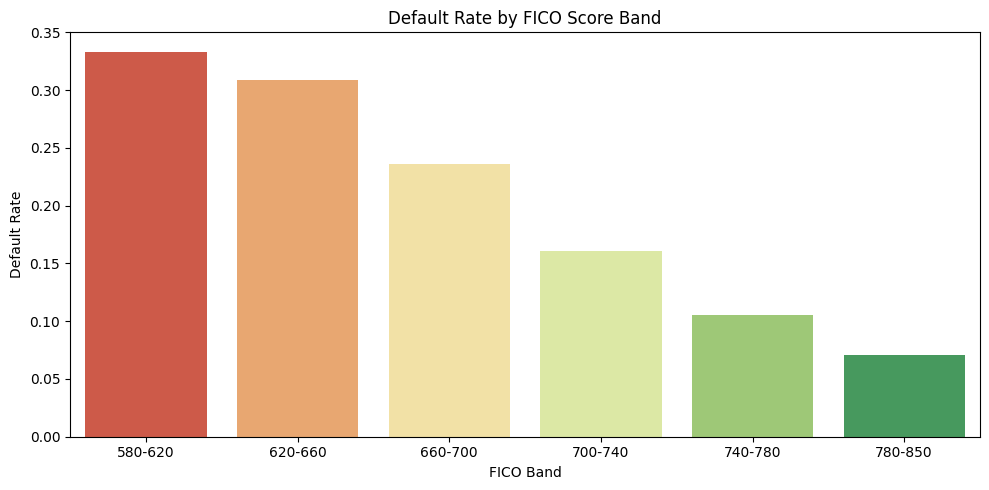

Business Insight: [Write what FICO cutoff the lender should enforce]


In [8]:
df['fico_band'] = pd.cut(df['fico_avg'],
    bins=[580, 620, 660, 700, 740, 780, 850],
    labels=['580-620', '620-660', '660-700', '700-740', '740-780', '780-850']
)

fico_dr = df.groupby('fico_band', observed=True)['default_flag'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=fico_dr, x='fico_band', y='default_flag', palette='RdYlGn')
plt.title('Default Rate by FICO Score Band')
plt.xlabel('FICO Band')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('../tableau/screenshots/default_rate_by_fico.png', dpi=150)
plt.show()
print('Business Insight: [Write what FICO cutoff the lender should enforce]')